In [ ]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from pricer.items import Item
from pricer.parser import parse
load_dotenv(override=True)

In [ ]:
# Log in to HuggingFace - if you get a "Note" about Environment variable being set, ignore it

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

In [ ]:
dataset = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw_meta_Appliances/full-00000-of-00001.parquet"
)

In [ ]:
print(f"Number of Appliances: {len(dataset):,}")

In [ ]:
# Investigate a particular datapoint

dataset[6]


In [ ]:

# What's the most expensive item?

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The most expensive item is {max_item['title']} and it costs {max_price:,.2f}")

In [ ]:
# ----------------------------------------------------------------------------------------
# 1. PARSING : before this We open parser.py and understand some important functions there
# ----------------------------------------------------------------------------------------
"""We have three things.

Item

Ed's custom data structure.

We'll come back to it.

json

Used because some of the raw product information is stored as JSON text.

re

Python's regular-expression module."""
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 2. The Curation Rules
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------


"""
We define:

MIN_CHARS = 600
MIN_PRICE = 0.5
MAX_PRICE = 999.49
MAX_TEXT_EACH = 3000
MAX_TEXT_TOTAL = 4000

This is important.

These are essentially his data-quality rules.

He's saying:

"For this project, I don't want every raw Amazon record. I want records satisfying certain conditions."

For example:

price
  ↓
$0.20        ❌
$50          ✅
$999         ✅
$5,000       ❌

And:

text length
  ↓
200 chars    ❌
800 chars    ✅

Why?

Because the model is ultimately going to learn:

PRODUCT DESCRIPTION → PRICE

So we want the product descriptions that contain enough useful information and prices that fall within the chosen range.

🟢 MUST UNDERSTAND

These constants are not magic ML parameters.

They're data-curation decisions.

That's an important distinction."""

# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 3. REMOVALS
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------

"""

Then:

REMOVALS = [
    "Part Number",
    "Best Sellers Rank",
    "Batteries Included?",
    "Batteries Required?",
    "Item model number",
]

This tells us:

Some information exists in the raw product metadata, but Ed doesn't consider it useful for the text that will eventually be given to the model.

For example:

Item model number → XYZ123ABC

That probably doesn't help much with:

"How much does this product cost?"

So he removes it.

Conceptually:

RAW PRODUCT
│
├── title                → KEEP
├── description          → KEEP
├── features             → KEEP
├── useful details       → KEEP
├── item model number    → REMOVE
├── best seller rank     → REMOVE
└── battery metadata     → REMOVE
🟢 MUST UNDERSTAND

Feature selection / information selection.

The exact list isn't something you need to memorize."""
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 5. simplify()
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------

"""

Now:

def simplify(text_list) -> str:

Inside:

return (
    str(text_list)
    .replace("\n", " ")
    .replace("\r", "")
    .replace("\t", "")
    .replace("  ", " ")
    .strip()[:MAX_TEXT_EACH]
)

Don't get distracted by all those .replace() calls.

The purpose is:

Take messy text and make it cleaner and bounded in size.

For example, imagine:

"Excellent product\n
\n
Great quality\t\t
Very durable"

becomes roughly:

"Excellent product Great quality Very durable"

And then:

[:MAX_TEXT_EACH]

limits it to 3000 characters.

🟡 UNDERSTAND THE IDEA

You don't need to memorize the chain of .replace() calls."""

# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 6. scrub() — this is where the real cleaning happens
#----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
"""def scrub(title, description, features, details) -> str:

Its job is basically:

Take all the useful product information and turn it into one clean text representation.

First:

for remove in REMOVALS:
    details.pop(remove, None)

So if details contains:

Part Number
Best Sellers Rank
Item model number

those get removed.

Then:

result = title + "\n"

Start with the title.

Then:

if description:
    result += simplify(description) + "\n"

If there's a description, clean it and append it.

Then:

if features:
    result += simplify(features) + "\n"

Same for features.

Then:

if details:
    result += json.dumps(details) + "\n"

Add the remaining useful metadata.

So we're essentially building:

                TITLE
                  +
             DESCRIPTION
                  +
               FEATURES
                  +
           USEFUL DETAILS
                  ↓
              FULL TEXT

This full text is extremely important because it becomes the textual representation of the product."""

# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 7. The regex
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
"""Then we have :

pattern = r"\b(?=[A-Z0-9]{7,}\b)(?=.*[A-Z])(?=.*\d)[A-Z0-9]+\b"
return re.sub(pattern, "", result).strip()[:MAX_TEXT_TOTAL]

This looks terrifying.

Don't learn it.

What does it do?

It identifies certain long alphanumeric codes containing both letters and numbers.

For example, something like:

B01D05U9NO

and removes it.

Why?

Because these kinds of product/model identifiers can be noise for the learning task.

🟡 Your required understanding:

"it uses a regex to remove product-code-like strings from the cleaned text."

That's enough.

You can ask me about regex separately if you ever need it."""


# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 8. get_weight()
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
"""Next:

def get_weight(details):

then we look for:

weight_str = details.get("Item Weight")

Suppose Amazon says:

"16 ounces"

Then:

parts = weight_str.split(" ")

gives roughly:

["16", "ounces"]

Then:

amount = float(parts[0])
unit = parts[1].lower()

So:

amount = 16
unit = ounces

Then:

elif unit == "ounces":
    return amount / 16

He converts ounces into pounds.

Likewise:

grams       → pounds
kilograms   → pounds
milligrams  → pounds
Why?

Because you don't want:

Product A → 2 pounds
Product B → 32 ounces
Product C → 907 grams

to represent three incompatible units.

Instead:

Product A → 2 pounds
Product B → 2 pounds
Product C → ~2 pounds
🟡 Understand the concept.

Don't memorize formulas."""


# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# Everything as a whole
# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
"""9. Now we reach the most important function: parse()
def parse(datapoint, category):

This is essentially the main gatekeeper.

A raw datapoint comes in:

RAW AMAZON RECORD
        ↓
      parse()
        ↓
 ┌───────────────┐
 │ Valid price?  │
 │ Good range?   │
 │ Good text?    │
 │ Clean it      │
 │ Normalize it  │
 └───────────────┘
        ↓
     Item

Let's walk through it.

Step 1 — validate price
try:
    price = float(datapoint["price"])
except ValueError:
    return None

If price isn't usable:

❌ → None

Remember what we discussed earlier.

Step 2 — price range
if MIN_PRICE <= price <= MAX_PRICE:

Only products between:

$0.50 → $999.49

are accepted.

Otherwise:

❌ discarded
Step 3 — extract information
title = datapoint["title"]
description = datapoint["description"]
features = datapoint["features"]
details = json.loads(datapoint["details"])

We're extracting the fields we care about.

Step 4 — normalize weight
weight = get_weight(details)
Step 5 — clean the text
full = scrub(title, description, features, details)

Now we have:

full = cleaned product information
Step 6 — minimum information requirement
if len(full) >= MIN_CHARS:

Remember:

MIN_CHARS = 600

So:

600+ characters → potentially useful
<600 characters → discard

Why?

Because we want enough descriptive information for the price-prediction task.

Step 7 — create an Item

Finally:

return Item(
    title=title,
    category=category,
    price=price,
    full=full,
    weight=weight,
)

So the raw Amazon record has now become a structured object.

The whole parse() function in your head

You should be able to visualize:

             RAW DATAPOINT
                   │
                   ▼
            Is price valid?
              /          \
            NO            YES
            │              │
            ▼              ▼
         discard       Price 0.5–999.49?
                         /       \
                       NO         YES
                       │           │
                       ▼           ▼
                    discard    Extract fields
                                   │
                                   ▼
                             Clean text
                                   │
                                   ▼
                             Normalize weight
                                   │
                                   ▼
                           Text ≥ 600 chars?
                              /        \
                            NO          YES
                            │            │
                            ▼            ▼
                         discard     Item(...)
🟢 THIS WHOLE FLOW = MUST UNDERSTAND."""


## SOME USEFUL INSIGHTS from our dataset
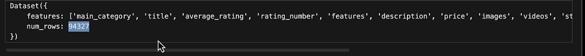
dataset[0]
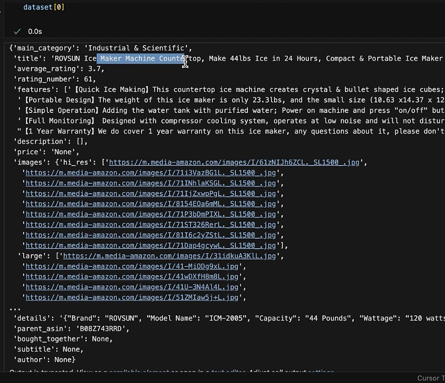
With actual price
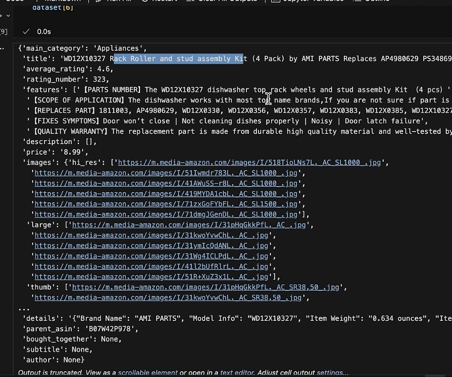




## PART 2 - Understand Items

In [ ]:
"""The Item object

We've just taken this:

RAW AMAZON DATAPOINT
        ↓
      parse()
        ↓
   cleaned product

Now look at what parse() returns:

return Item(
    title=title,
    category=category,
    price=price,
    full=full,
    weight=weight,
)

So the obvious question is:

What exactly is Item?

That's what items.py defines.

1. Item is a structured representation of one product

At the top:

from pydantic import BaseModel
from datasets import Dataset, DatasetDict, load_dataset
from typing import Optional, Self

Then:

class Item(BaseModel):

Think of Item as a schema/template for a product.

Instead of having arbitrary raw dictionaries floating around, Ed says:

"Every cleaned product should have this particular structure."

The structure is:

title: str
category: str
price: float
full: Optional[str] = None
weight: Optional[float] = None
summary: Optional[str] = None
prompt: Optional[str] = None
id: Optional[int] = None

So conceptually:

                 Item
        ┌──────────────────┐
        │ title            │
        │ category         │
        │ price            │
        │ full             │
        │ weight           │
        │ summary          │
        │ prompt           │
        │ id               │
        └──────────────────┘
🟢 MUST UNDERSTAND

Structured data.

This is a concept you're going to see constantly in LLM engineering.

You've already encountered Pydantic in your own projects, so this should feel familiar.

2. Why not just use dictionaries?

You could have:

product = {
    "title": "...",
    "category": "...",
    "price": 129.99,
}

But with Item, we establish a consistent structure.

Every object is expected to have:

title → string
category → string
price → float
...

That gives the rest of the pipeline something predictable to work with.

Think about your own RAG/security projects.

You might eventually define:

class Vulnerability(BaseModel):
    cve_id: str
    description: str
    severity: float
    attack_vector: str
    ...

Now every vulnerability has a known structure.

That's exactly the kind of thinking you should take away from this.

3. What does BaseModel give us?

we write:

class Item(BaseModel):

BaseModel comes from Pydantic.

The important idea for you is:

Pydantic lets us define structured data with typed fields and validation.

For example:

price: float

means price is intended to be a numeric value.

You don't need to go deep into Pydantic internals here.

🟢 Understand:
Pydantic BaseModel
        ↓
structured + validated data
4. Optional

You see:

full: Optional[str] = None

This means:

full can contain a string, but it is allowed to be absent/None.

Same idea for:

weight: Optional[float] = None
summary: Optional[str] = None
prompt: Optional[str] = None
id: Optional[int] = None
🟡 Understand the idea.

You don't need to memorize the typing syntax.

5. Now something interesting: make_prompt()

This is where we start moving toward the actual ML/LLM part.

def make_prompt(self, text: str):
    self.prompt = f"{QUESTION}\n\n{text}\n\n{PREFIX}{round(self.price)}.00"

Remember:

QUESTION = "What does this cost to the nearest dollar?"
PREFIX = "Price is $"

So suppose:

text =
"Stainless steel microwave oven with..."

and:

price = 129.49

Then Ed constructs something approximately like:

What does this cost to the nearest dollar?

Stainless steel microwave oven with...

Price is $129.00
🚨 🟢 THIS IS IMPORTANT

Now we're creating a training example.

The model will eventually see the product description and learn to predict the price.

Conceptually:

                  TRAINING EXAMPLE

INPUT
────────────────────────────────────
What does this cost?

Product description...
────────────────────────────────────

TARGET
────────────────────────────────────
Price is $129.00
────────────────────────────────────

This is much more important for you to understand than the exact Python f-string syntax.

6. Why is the price placed at the end?

This is deliberate.

we are constructing a prompt where:

description → answer

The model eventually has to learn the relationship between the product information and the price.

So:

PRODUCT INFORMATION
        ↓
      MODEL
        ↓
     PRICE

This is the fundamental task of the capstone.

7. test_prompt()

Now:

def test_prompt(self) -> str:
    return self.prompt.split(PREFIX)[0] + PREFIX

This one is really worth understanding.

Remember our training prompt:

What does this cost?

Product description...

Price is $129.00

During testing, we don't want to give the model the answer.

So test_prompt() effectively creates:

What does this cost?

Product description...

Price is $

And then the model has to complete it.

Conceptually:

TRAINING
─────────────────────────
Product → Price
Product → Price
Product → Price
Product → Price
       ↓
     MODEL
─────────────────────────

TEST
─────────────────────────
New Product → Price?
              ↓
           MODEL
              ↓
           "$129"
🟢 MUST UNDERSTAND

This is the fundamental distinction:

Training examples contain the target.

Test prompts hide the target.

8. __repr__

Then:

def __repr__(self) -> str:
    return f"<{self.title} = ${self.price}>"

This simply controls how an Item looks when you print it.

So instead of a giant object representation, you might see:

<Stainless Steel Microwave = $129.99>
🔴 Don't spend time on this.

It's convenience/debugging code."""

## NOW the Hugging Face Part

In [ ]:
"""Then:

@staticmethod
def push_to_hub(
    dataset_name: str,
    train: list[Self],
    val: list[Self],
    test: list[Self]
):

This is essentially saying:

"Take my Python Item objects and save them as a Hugging Face dataset."

Inside:

Dataset.from_list(
    [item.model_dump() for item in train]
)

The important transformation is:

Item objects
     ↓
model_dump()
     ↓
Python dictionaries
     ↓
Hugging Face Dataset

Then:

DatasetDict({
    "train": ...,
    "validation": ...,
    "test": ...
})

creates the three splits.

Finally:

.push_to_hub(dataset_name)

uploads them.

🟢 Understand the pipeline.

Don't memorize the Hugging Face API syntax.

10. from_hub()

The reverse operation is:

@classmethod
def from_hub(...)

It does:

Hugging Face dataset
        ↓
load_dataset()
        ↓
rows
        ↓
Item objects

Specifically:

[cls.model_validate(row) for row in ds["train"]]

means roughly:

"Take each dataset row and reconstruct a validated Item object from it."""

In [ ]:
# Load into Item objects if they have a price range $1-$1000 and enough details

items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

In [ ]:
# Here is a clean diagram of what we are actually doing
"""DatasetDict(
    {
        "train":
            Dataset.from_list(
                [item.model_dump() for item in train]
            ),

        "validation":
            Dataset.from_list(
                [item.model_dump() for item in val]
            ),

        "test":
            Dataset.from_list(
                [item.model_dump() for item in test]
            ),
    }
)"""

In [ ]:
print(items[0].full)

In [ ]:
print(items[0].full)

In [ ]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

In [ ]:
# Don't Need to memorize this use LLM
# Plot the distribution of lengths

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

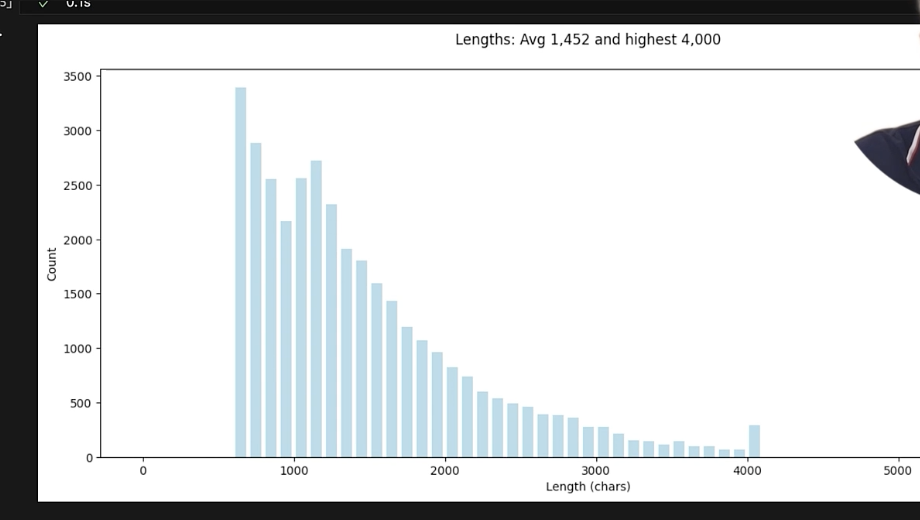

In [ ]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)


In [ ]:
# AGAIN USE LLMs For this KINDA thing
# Plot the distribution of prices
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

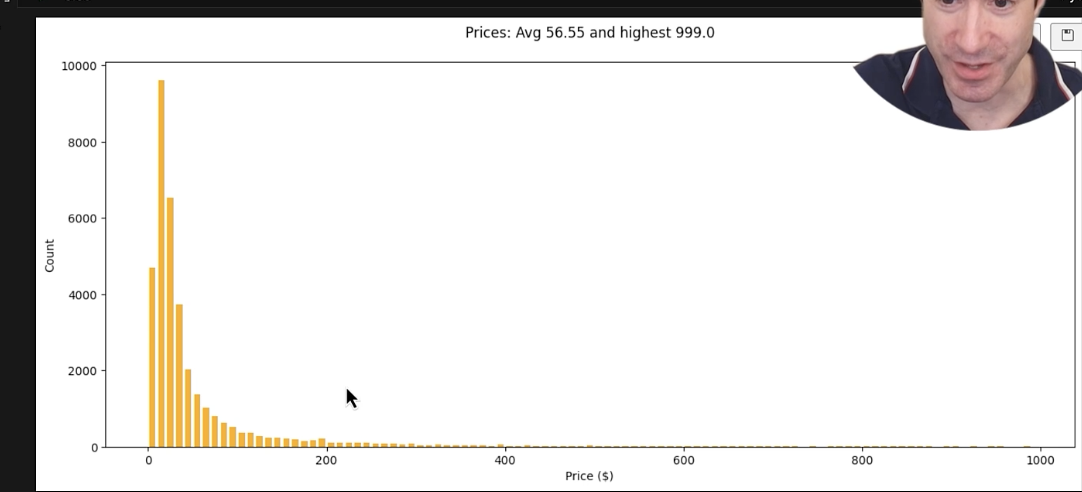

In [ ]:
print(items[3].full)

In [ ]:
from pricer.loaders import ItemLoader
loader = ItemLoader("Appliances")
items = loader.load()


In [ ]:

dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

In [ ]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

In [ ]:
print(f"A grand total of {len(items):,} items")

In [ ]:
items[1000]

In [ ]:
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

In [ ]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths) / len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

In [ ]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices) / len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [ ]:
from collections import Counter

category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [ ]:
print(items[3].full)
from pricer.loaders import ItemLoader

loader = ItemLoader("Appliances")
items = loader.load()

dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())
print(f"A grand total of {len(items):,} items")
items[1000]
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths) / len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices) / len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()
from collections import Counter

category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()
np.random.seed(42)

SIZE = 820_000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p ** 2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]


In [ ]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [ ]:
# Just for good measure, let's shuffle the sample again for the final dataset

random.seed(42)
random.shuffle(sample)

In [ ]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices) / len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [ ]:
from collections import Counter
category_counts = Counter([item.category for item in sample])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

In [ ]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

plt.show()

In [ ]:
# How does the price vary with the character count?

sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')

# Display the plot
plt.show()

In [ ]:
# How does the price vary with the weight?

ounces = [item.weight for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")

# Add labels and title
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')

# Display the plot
plt.show()

In [ ]:
username = "ed-donner"
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

train = sample[:800_000]
val = sample[800_000:810_000]
test = sample[810_000:]

Item.push_to_hub(full, train, val, test)

train_lite = train[:20_000]
val_lite = val[:1_000]
test_lite = test[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)